<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%203/1_week3_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: EDA — QPon Google Play Reviews
Re-run of dosen's EDA notebook + Kaggle examples, using QPon app review data.

**Input:** `df_qpon_rev.csv` (from Week 2 scrapping assignment)

In [ ]:
!pip install pandas matplotlib seaborn nltk Sastrawi wordcloud -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
import string
import re
from wordcloud import WordCloud
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

---
## 1. Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()  # upload df_qpon_rev.csv

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded {fn}: {len(df):,} rows')

Saving df_qpon_rev.csv to df_qpon_rev (1).csv
Loaded df_qpon_rev (1).csv: 4,684 rows


In [ ]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1


---
## 2. Data Overview

In [ ]:
df['at'] = pd.to_datetime(df['at'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4684 entries, 0 to 4683
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              4684 non-null   object        
 1   userName              4684 non-null   object        
 2   userImage             4684 non-null   object        
 3   content               4684 non-null   object        
 4   score                 4684 non-null   int64         
 5   thumbsUpCount         4684 non-null   int64         
 6   reviewCreatedVersion  3637 non-null   object        
 7   at                    4684 non-null   datetime64[ns]
 8   replyContent          2772 non-null   object        
 9   repliedAt             2772 non-null   object        
 10  appVersion            3637 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 402.7+ KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1


In [ ]:
# missing values
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Missing values:
reviewCreatedVersion    1047
replyContent            1912
repliedAt               1912
appVersion              1047
dtype: int64


---
## 3. Review Score Distribution

/tmp/ipykernel_485/3265126195.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['score'], palette='viridis')


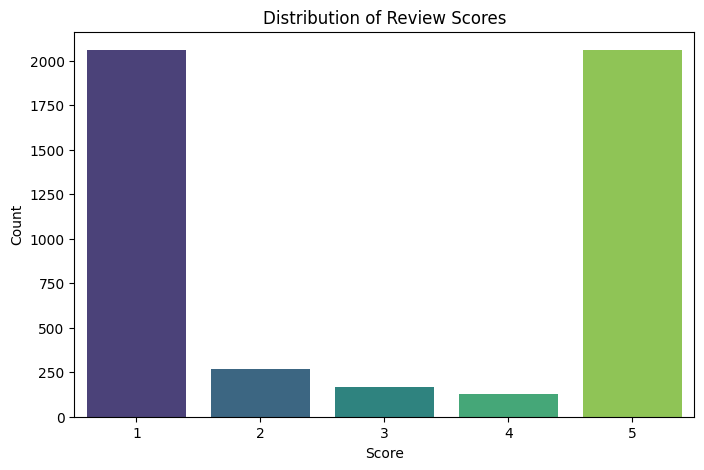

score
1    2059
2     269
3     169
4     130
5    2057
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['score'], palette='viridis')
plt.title('Distribution of Review Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

print(df['score'].value_counts().sort_index())

---
## 4. Reviews per Year

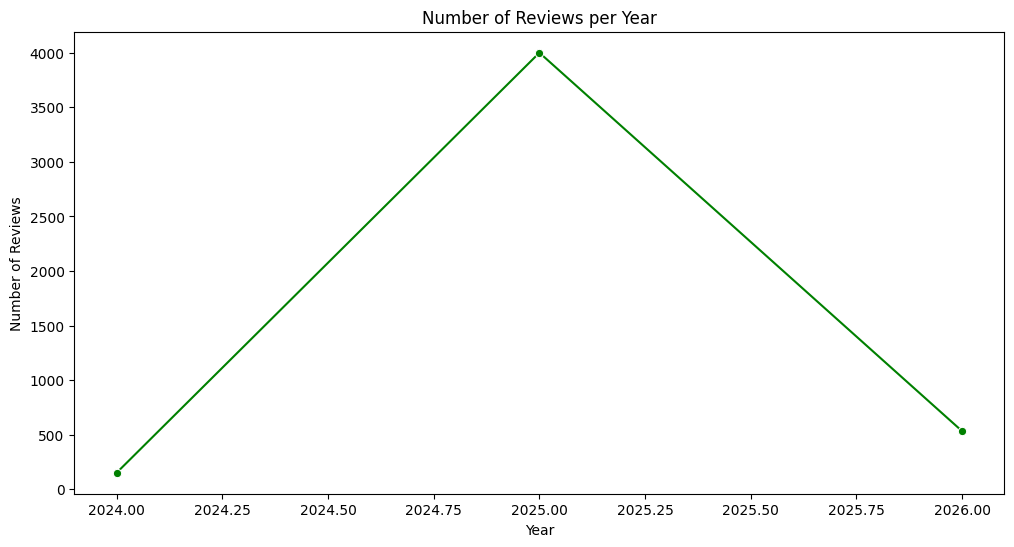

In [ ]:
df['year'] = df['at'].dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

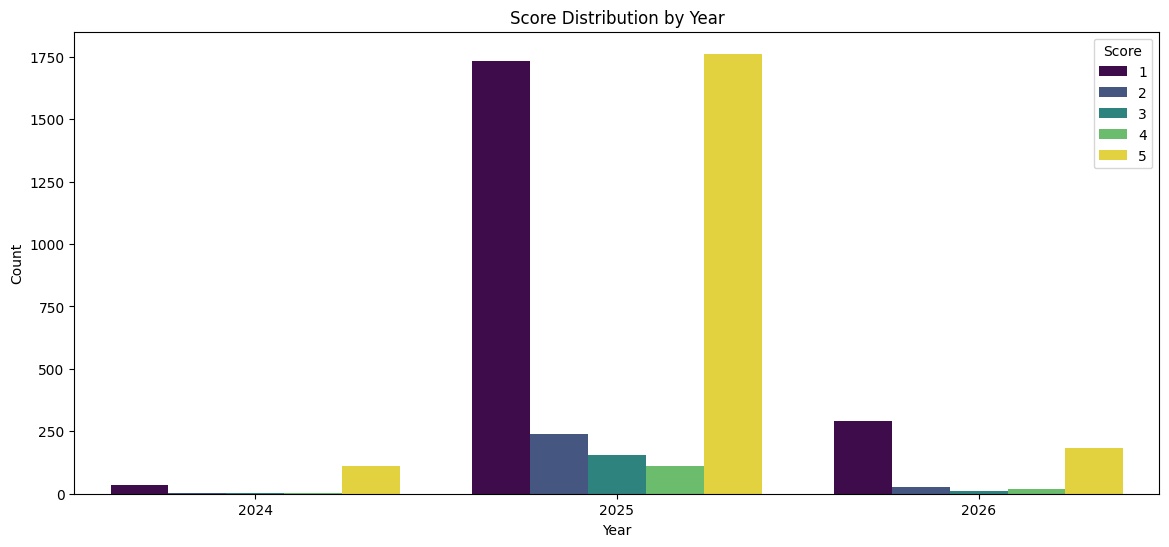

In [ ]:
# score distribution per year
plt.figure(figsize=(14, 6))
sns.countplot(x='year', hue='score', data=df, palette='viridis')
plt.title('Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

---
## 5. Review Trends Over Time

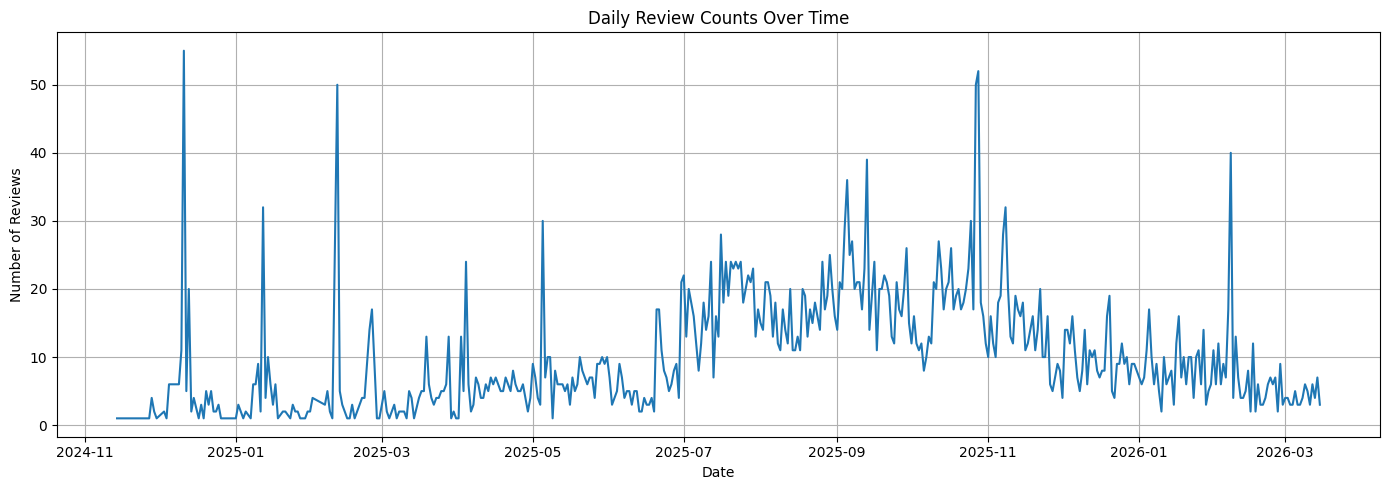

In [ ]:
df['review_date'] = df['at'].dt.date
review_trend = df.groupby('review_date').size()

plt.figure(figsize=(14, 5))
review_trend.plot()
plt.title('Daily Review Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.tight_layout()
plt.show()

---
## 6. Word Frequency Analysis

/tmp/ipykernel_485/3063384834.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='word', y='count', palette='viridis')


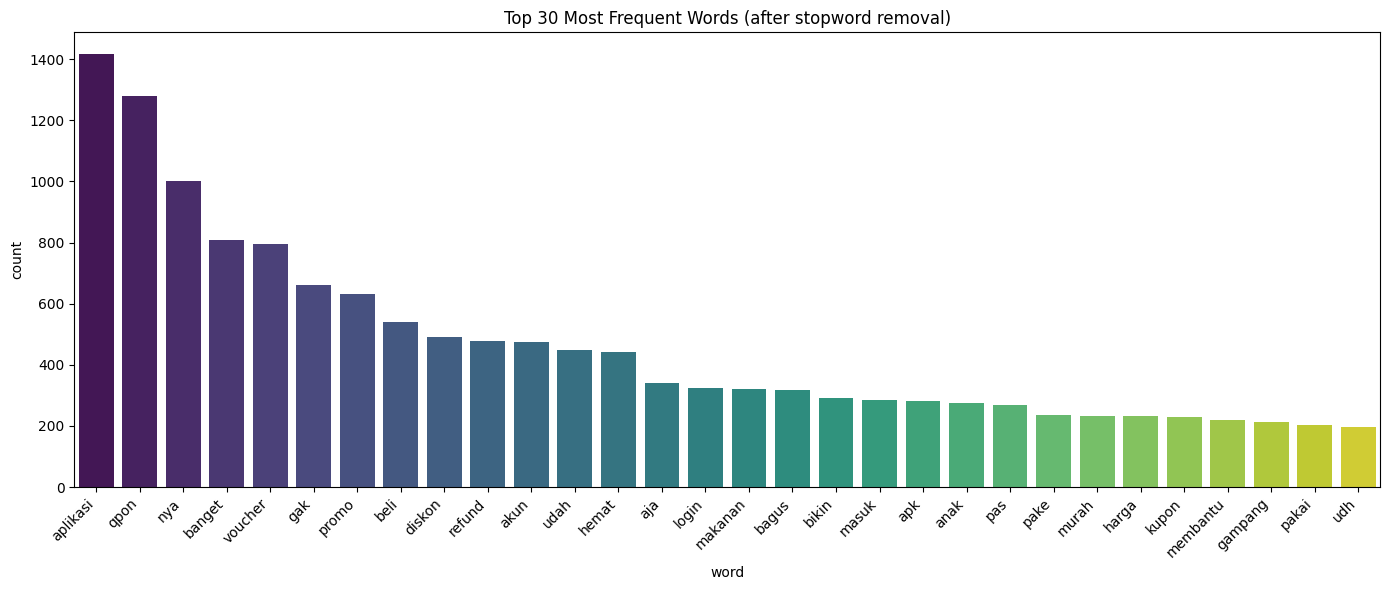

In [ ]:
all_reviews = ' '.join(df['content'].dropna().astype(str)).lower()
all_reviews = all_reviews.translate(str.maketrans('', '', string.punctuation))

words = all_reviews.split()
filtered = [w for w in words if w not in stop_words and len(w) > 2]
word_counts = Counter(filtered)

top30 = word_counts.most_common(30)
top_df = pd.DataFrame(top30, columns=['word', 'count'])

plt.figure(figsize=(14, 6))
sns.barplot(data=top_df, x='word', y='count', palette='viridis')
plt.title('Top 30 Most Frequent Words (after stopword removal)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Word Cloud

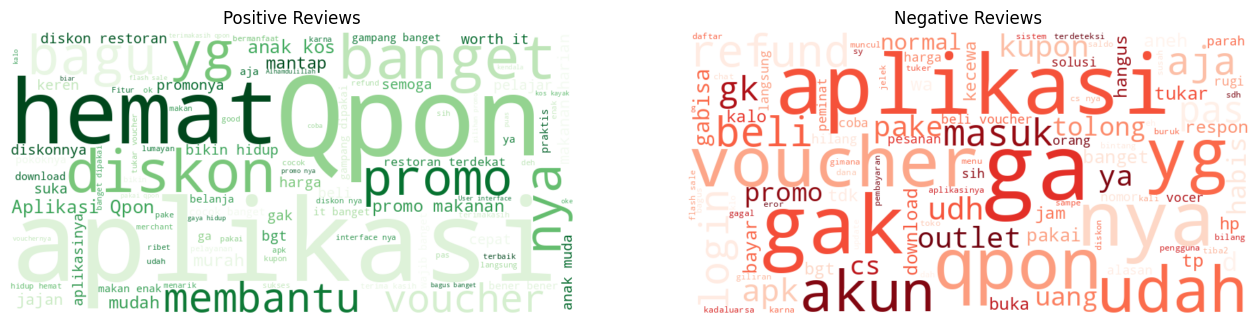

In [ ]:
# sentiment label
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

def make_cloud(text, title, cmap):
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100,
                   stopwords=stop_words).generate(text)
    return wc

pos_text = ' '.join(df[df['sentiment'] == 'positive']['content'].dropna().astype(str))
neg_text = ' '.join(df[df['sentiment'] == 'negative']['content'].dropna().astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(make_cloud(pos_text, 'Positive', 'Greens'), interpolation='bilinear')
axes[0].set_title('Positive Reviews')
axes[0].axis('off')

axes[1].imshow(make_cloud(neg_text, 'Negative', 'Reds'), interpolation='bilinear')
axes[1].set_title('Negative Reviews')
axes[1].axis('off')
plt.show()